<a href="https://colab.research.google.com/github/PabloShol/simulacion2/blob/main/Proyecto_SIR_con_PyMC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pymc pytensor

/tmp/ipykernel_1145/2008995722.py:18: FutureWarning: pytensor.as_op is deprecated and will be removed in a future release. Please use pytensor.wrap_py instead.
  @as_op(itypes=[pt.dscalar, pt.dscalar, pt.dscalar], otypes=[pt.dvector])


Iniciando el muestreo bayesiano con PyMC... (Esto puede tardar 1-2 minutos)


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



--- RESUMEN ESTADÍSTICO DE LA POSTERIOR ---
           mean       sd   hdi_3%   hdi_97%
beta      1.779    0.081    1.658     1.948
gamma     0.595    0.096    0.439     0.776
N      1018.086  170.721  763.012  1368.053
sigma    18.630    3.785   11.922    25.051

R0 Bayesiano Promedio (Beta/Gamma): 2.99



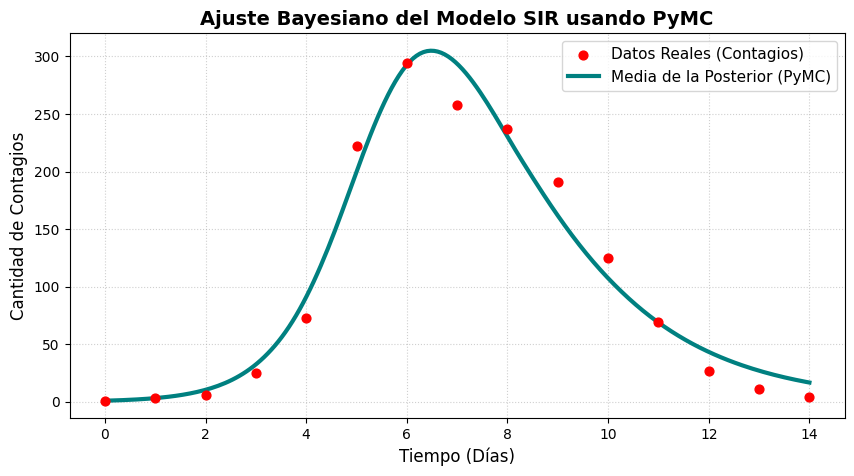

In [6]:
import pymc as pm
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pytensor.tensor as pt
from pytensor.compile.ops import as_op

tiempo_real = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
contagios_real = np.array([1,3,6,25,73,222,294,258,237,191,125,69,27,11,4])

# Modelo SIR determinista (Función de SciPy envuelta para PyMC)
def ed_sir(t, y, beta, gamma, N):
    S, I, R = y
    return [-beta * S * I / N, (beta * S * I / N) - (gamma * I), gamma * I]

# Convertimos la simulación numérica en un operador compatible con PyMC usando Pytensor
@as_op(itypes=[pt.dscalar, pt.dscalar, pt.dscalar], otypes=[pt.dvector])
def simulacion_sir_op(beta, gamma, N):
    I0 = contagios_real[0]
    y0 = [N - I0, I0, 0.0]
    sol = solve_ivp(ed_sir, (tiempo_real[0], tiempo_real[-1]), y0, args=(beta, gamma, N), t_eval=tiempo_real)
    # Si la integración falla, devolvemos un vector de ceros para no romper la cadena
    if sol.status != 0:
        return np.zeros_like(tiempo_real)
    return sol.y[1] # Retorna únicamente la curva de Infectados (I)

# Construcción del Modelo Bayesiano en PyMC
with pm.Model() as modelo_bayesiano:

    # Prioris (Distribuciones previas basadas en conocimiento del problema)
    beta = pm.Uniform("beta", lower=0.5, upper=3.0)
    gamma = pm.Uniform("gamma", lower=0.1, upper=1.5)
    N = pm.Uniform("N", lower=500, upper=2000)

    # Desviación estándar del error de medición (Incertidumbre de los datos)
    sigma = pm.HalfNormal("sigma", sigma=15)

    # Conectar la simulación numérica del modelo SIR
    curva_infectados = simulacion_sir_op(beta, gamma, N)

    # Verosimilitud (Likelihood): Asumimos que los datos reales siguen una distribución Normal
    # centrada en la predicción del modelo SIR
    observaciones = pm.Normal("observaciones", mu=curva_infectados, sigma=sigma, observed=contagios_real)

# Muestreo de la distribución posterior
    print("Iniciando el muestreo bayesiano con PyMC... (Esto puede tardar 1-2 minutos)")

    trace = pm.sample(draws=2000, tune=1000, step=pm.Metropolis(), chains=2, random_seed=42)

# Extracción de estadísticas de los parámetros ajustados
summary = pm.summary(trace, var_names=["beta", "gamma", "N", "sigma"])
print("\n--- RESUMEN ESTADÍSTICO DE LA POSTERIOR ---")
print(summary[["mean", "sd", "hdi_3%", "hdi_97%"]])

beta_medio = summary.loc["beta", "mean"]
gamma_medio = summary.loc["gamma", "mean"]
N_medio = summary.loc["N", "mean"]

print(f"\nR0 Bayesiano Promedio (Beta/Gamma): {beta_medio/gamma_medio:.2f}\n")

# Graficar la solución con los parámetros del promedio posterior
t_curva = np.linspace(tiempo_real[0], tiempo_real[-1], 200)
y0_bayes = [N_medio - contagios_real[0], contagios_real[0], 0.0]
sol_bayes = solve_ivp(ed_sir, (tiempo_real[0], tiempo_real[-1]), y0_bayes, args=(beta_medio, gamma_medio, N_medio), t_eval=t_curva)

plt.figure(figsize=(10, 5))
plt.scatter(tiempo_real, contagios_real, color='red', s=40, label='Datos Reales (Contagios)', zorder=5)
plt.plot(t_curva, sol_bayes.y[1], color='teal', linewidth=3, label='Media de la Posterior (PyMC)')
plt.title('Ajuste Bayesiano del Modelo SIR usando PyMC', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (Días)', fontsize=12)
plt.ylabel('Cantidad de Contagios', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()